In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'\Users\lenovo\Downloads\drug-response-app\data\real_drug_dataset.csv')
df.head(5)
print(df.shape)


(1000, 9)


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               1000 non-null   str    
 1   Age                      1000 non-null   int64  
 2   Gender                   1000 non-null   str    
 3   Condition                1000 non-null   str    
 4   Drug_Name                1000 non-null   str    
 5   Dosage_mg                1000 non-null   int64  
 6   Treatment_Duration_days  1000 non-null   int64  
 7   Side_Effects             1000 non-null   str    
 8   Improvement_Score        1000 non-null   float64
dtypes: float64(1), int64(3), str(5)
memory usage: 70.4 KB


In [36]:
df.describe()

,Age,Dosage_mg,Treatment_Duration_days,Improvement_Score
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,49.857000,352.650000,32.38000,7.015200
std,18.114267,295.419617,15.69809,1.425609
min,18.000000,50.000000,5.00000,2.500000
25%,35.000000,100.000000,19.00000,6.100000
50%,50.000000,250.000000,32.00000,7.000000
75%,66.000000,500.000000,46.00000,8.000000
max,79.000000,850.000000,59.00000,10.000000


In [16]:
df.isnull().sum()

Patient_ID                 0
Age                        0
Gender                     0
Condition                  0
Drug_Name                  0
Dosage_mg                  0
Treatment_Duration_days    0
Side_Effects               0
Improvement_Score          0
dtype: int64

In [18]:
df.columns.tolist()

['Patient_ID',
 'Age',
 'Gender',
 'Condition',
 'Drug_Name',
 'Dosage_mg',
 'Treatment_Duration_days',
 'Side_Effects',
 'Improvement_Score']

In [59]:
df['Drug_Name'].value_counts()

Drug_Name
Tramadol            82
Ciprofloxacin       79
Insulin Glargine    78
Amlodipine          74
Azithromycin        70
Glipizide           67
Bupropion           66
Losartan            66
Amoxicillin         66
Ibuprofen           64
Paracetamol         62
Metformin           62
Escitalopram        55
Sertraline          55
Metoprolol          54
Name: count, dtype: int64

In [20]:
print(df.isnull().sum())

Patient_ID                 0
Age                        0
Gender                     0
Condition                  0
Drug_Name                  0
Dosage_mg                  0
Treatment_Duration_days    0
Side_Effects               0
Improvement_Score          0
dtype: int64


In [22]:
print(df['Drug_Name'].value_counts())

Drug_Name
Tramadol            82
Ciprofloxacin       79
Insulin Glargine    78
Amlodipine          74
Azithromycin        70
Glipizide           67
Bupropion           66
Losartan            66
Amoxicillin         66
Ibuprofen           64
Paracetamol         62
Metformin           62
Escitalopram        55
Sertraline          55
Metoprolol          54
Name: count, dtype: int64


In [24]:
print(df['Drug_Name'].duplicated().value_counts())

Drug_Name
True     985
False     15
Name: count, dtype: int64


In [25]:
print("Duplicate patient IDs:", df['Patient_ID'].duplicated().sum())

Duplicate patient IDs: 0


In [60]:
df.describe()

,Age,Dosage_mg,Treatment_Duration_days,Improvement_Score
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,49.857000,352.650000,32.38000,7.015200
std,18.114267,295.419617,15.69809,1.425609
min,18.000000,50.000000,5.00000,2.500000
25%,35.000000,100.000000,19.00000,6.100000
50%,50.000000,250.000000,32.00000,7.000000
75%,66.000000,500.000000,46.00000,8.000000
max,79.000000,850.000000,59.00000,10.000000


In [27]:
for col in ["Gender","Condition","Drug_Name","Side_Effects"]:
    print(f"\n {col}:{df[col].value_counts()}")
    print(df[col].value_counts())


 Gender:Gender
Male      523
Female    477
Name: count, dtype: int64
Gender
Male      523
Female    477
Name: count, dtype: int64

 Condition:Condition
Infection       215
Pain Relief     208
Diabetes        207
Hypertension    194
Depression      176
Name: count, dtype: int64
Condition
Infection       215
Pain Relief     208
Diabetes        207
Hypertension    194
Depression      176
Name: count, dtype: int64

 Drug_Name:Drug_Name
Tramadol            82
Ciprofloxacin       79
Insulin Glargine    78
Amlodipine          74
Azithromycin        70
Glipizide           67
Bupropion           66
Losartan            66
Amoxicillin         66
Ibuprofen           64
Paracetamol         62
Metformin           62
Escitalopram        55
Sertraline          55
Metoprolol          54
Name: count, dtype: int64
Drug_Name
Tramadol            82
Ciprofloxacin       79
Insulin Glargine    78
Amlodipine          74
Azithromycin        70
Glipizide           67
Bupropion           66
Losartan            6

In [29]:
df.groupby("Condition")["Drug_Name"].unique()

Condition
Depression           [Bupropion, Escitalopram, Sertraline]
Diabetes          [Glipizide, Metformin, Insulin Glargine]
Hypertension            [Metoprolol, Amlodipine, Losartan]
Infection       [Ciprofloxacin, Azithromycin, Amoxicillin]
Pain Relief             [Paracetamol, Ibuprofen, Tramadol]
Name: Drug_Name, dtype: object

In [33]:
df.groupby("Drug_Name")["Dosage_mg"].unique()

Drug_Name
Amlodipine          [50, 100, 500, 850, 250]
Amoxicillin         [250, 850, 500, 100, 50]
Azithromycin        [50, 500, 250, 850, 100]
Bupropion           [100, 850, 50, 250, 500]
Ciprofloxacin       [50, 850, 500, 100, 250]
Escitalopram        [850, 500, 250, 100, 50]
Glipizide           [850, 250, 500, 100, 50]
Ibuprofen           [850, 50, 500, 100, 250]
Insulin Glargine    [500, 850, 100, 250, 50]
Losartan            [100, 850, 250, 50, 500]
Metformin           [850, 500, 250, 50, 100]
Metoprolol          [500, 100, 850, 250, 50]
Paracetamol         [100, 850, 500, 250, 50]
Sertraline          [500, 250, 850, 100, 50]
Tramadol            [50, 850, 250, 500, 100]
Name: Dosage_mg, dtype: object

In [34]:
print("Duplicate rows : ",df.duplicated().sum())

Duplicate rows :  0


In [35]:
print("Duplicated patient IDs :",df['Patient_ID'].duplicated().sum())

Duplicated patient IDs : 0


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "whitegrid")

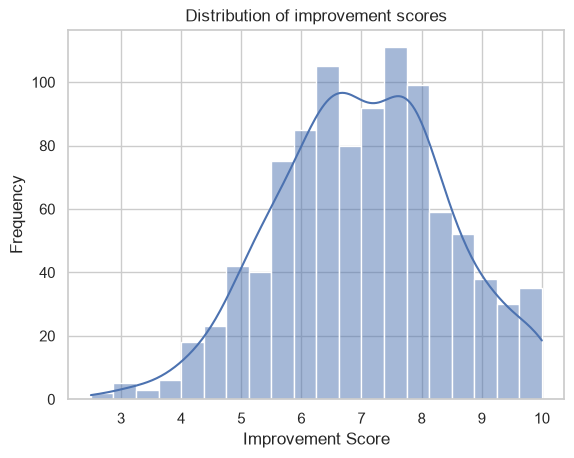

In [41]:
sns.histplot(df["Improvement_Score"], bins = 20, kde = True)
plt.title("Distribution of improvement scores")
plt.xlabel("Improvement Score")
plt.ylabel("Frequency")
plt.show()

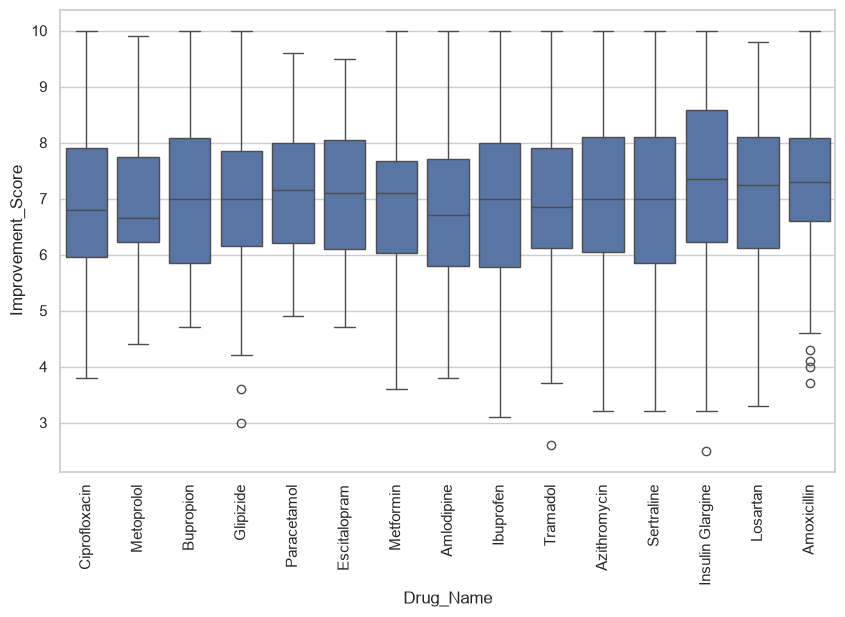

In [42]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = df,x="Drug_Name",y="Improvement_Score")
plt.xticks(rotation = 90)
plt.show()

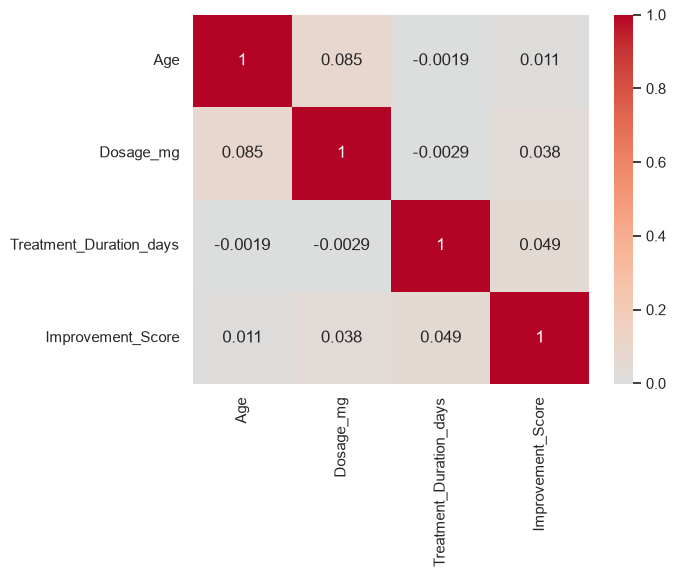

In [48]:
sns.heatmap(df[["Age","Dosage_mg",
"Treatment_Duration_days","Improvement_Score"]].corr(), annot = True, cmap = "coolwarm",center = 0)
plt.show()

In [43]:
df.columns.tolist()

['Patient_ID',
 'Age',
 'Gender',
 'Condition',
 'Drug_Name',
 'Dosage_mg',
 'Treatment_Duration_days',
 'Side_Effects',
 'Improvement_Score']

In [49]:
pd.crosstab(df["Drug_Name"], df["Side_Effects"])

Side_Effects,Abdominal pain,Allergy,Anxiety,Back pain,Constipation,Cough,Diarrhea,Dizziness,Drowsiness,Dry mouth,...,Rash,Skin rash,Sleep issues,Slow heartbeat,Stomach pain,Stomach upset,Sweating,Swelling,Tiredness,Weight gain
Drug_Name,,,,,,,,,,,,,,,,,,,,,
Amlodipine,0,0,0,0,0,0,0,27,0,0,...,0,0,0,0,0,0,0,18,0,0
Amoxicillin,0,23,0,0,0,0,19,0,0,0,...,24,0,0,0,0,0,0,0,0,0
Azithromycin,13,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bupropion,0,0,24,0,0,0,0,0,0,18,...,0,0,0,0,0,0,0,0,0,0
Ciprofloxacin,0,0,0,0,0,0,0,28,0,0,...,0,0,0,0,0,0,0,0,0,0
Escitalopram,0,0,0,0,0,0,0,0,0,0,...,0,0,21,0,0,0,16,0,0,0
Glipizide,0,0,0,0,0,0,0,0,0,0,...,0,19,0,0,0,0,0,0,0,0
Ibuprofen,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,29,0,0,0,0,0
Insulin Glargine,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,26


In [52]:
df["Side_Effects"] = df["Side_Effects"].replace({"Skin Rash": "Rash"})
df

,Patient_ID,Age,Gender,Condition,Drug_Name,Dosage_mg,Treatment_Duration_days,Side_Effects,Improvement_Score
0,P0001,56,Male,Infection,Ciprofloxacin,50,9,Nausea,8.5
1,P0002,69,Male,Hypertension,Metoprolol,500,24,Tiredness,8.7
2,P0003,46,Female,Depression,Bupropion,100,25,Dry mouth,5.4
3,P0004,32,Male,Diabetes,Glipizide,850,44,Low blood sugar,6.4
4,P0005,60,Male,Depression,Bupropion,850,35,Anxiety,5.3
...,...,...,...,...,...,...,...,...,...
995,P0996,18,Male,Hypertension,Losartan,100,44,Headache,7.7
996,P0997,35,Female,Infection,Azithromycin,50,15,Nausea,5.3
997,P0998,49,Female,Depression,Sertraline,850,52,Dry mouth,8.0
998,P0999,64,Male,Depression,Escitalopram,850,36,Nausea,7.6


In [57]:
from scipy import stats

groups = [g["Improvement_Score"].values for _, g in df.groupby("Drug_Name")]
f_stats, p_value = stats.f_oneway(*groups)
print(f"F = {f_stats:.3f},p = {p_value:.4f}")

F = 0.475,p = 0.9468


In [58]:
for col in ["Condition","Gender"]:
    groups = [g["Improvement_Score"].values for _, g in df.groupby(col)]
    print(col, stats.f_oneway(*groups))

Condition F_onewayResult(statistic=np.float64(0.5228134597507225), pvalue=np.float64(0.7189970925699813))
Gender F_onewayResult(statistic=np.float64(0.08452990905374617), pvalue=np.float64(0.7713103708265481))


In [77]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

X = df[['Patient_ID',
 'Age',
 'Gender',
 'Condition',
 'Drug_Name',
 'Dosage_mg',
 'Treatment_Duration_days',
 'Side_Effects']]

y = df['Improvement_Score']

pre = ColumnTransformer([
    ("Cat", OneHotEncoder(handle_unknown ='ignore'),['Gender', 'Drug_Name']),
    ("Num", StandardScaler(), ['Age', 'Dosage_mg', 'Treatment_Duration_days'])
    ])


In [63]:
df.columns.tolist()

['Patient_ID',
 'Age',
 'Gender',
 'Condition',
 'Drug_Name',
 'Dosage_mg',
 'Treatment_Duration_days',
 'Side_Effects',
 'Improvement_Score']

In [79]:
models = {"Baseline(Always Predict Mean)" : DummyRegressor(strategy = "mean")
        ,"LinearRegression" : LinearRegression(),
        "RandomForest" : RandomForestRegressor(n_estimators = 200,random_state=42)  
         }

In [80]:
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

In [81]:
for name , model in models.items():
    pipe = Pipeline([("pre", pre),("models", model)])
    r2 = cross_val_score(pipe, X, y, cv=cv, scoring = "r2")
    mae = -cross_val_score(pipe, X, y, cv=cv, scoring = "neg_mean_absolute_error")
    print(f"{name:32s}  R2 = {r2.mean():.3f} MAE = {mae.mean():.3f} ")

Baseline(Always Predict Mean)     R2 = -0.012 MAE = 1.155 
LinearRegression                  R2 = -0.039 MAE = 1.168 
RandomForest                      R2 = -0.113 MAE = 1.201 


In [82]:
y_shuffled = y.sample(frac = 1, random_state = 42).reset_index(drop=True)

for name , model in models.items():
    pipe = Pipeline([("pre", pre),("models", model)])
    r2 = cross_val_score(pipe, X, y_shuffled, cv=cv, scoring = "r2")
    mae = -cross_val_score(pipe, X, y_shuffled, cv=cv, scoring = "neg_mean_absolute_error")
    print(f"{name:32s}  R2 = {r2.mean():.3f} MAE = {mae.mean():.3f} ")

Baseline(Always Predict Mean)     R2 = -0.005 MAE = 1.154 
LinearRegression                  R2 = -0.033 MAE = 1.171 
RandomForest                      R2 = -0.170 MAE = 1.241 


In [83]:
import joblib 
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


In [84]:
side_model = Pipeline([
    ("pre",ColumnTransformer([("cat", OneHotEncoder(handle_unknown ='ignore'),["Drug_Name"])])),
    ("model", LogisticRegression(max_iter=2000)),
])

side_model.fit(df[["Drug_Name"]], df[["Side_Effects"]])

joblib.dump(side_model, "../side_effects_model.joblib")
print("saved")

c:\Users\lenovo\Downloads\drug-response-app\venv\Lib\site-packages\sklearn\utils\validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


saved
